<a href="https://colab.research.google.com/github/Marcel-12345/PCVK_Ganjil_2026/blob/main/Week6_244107020141.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Anselmus Marcel Putra Andria 244107020141
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


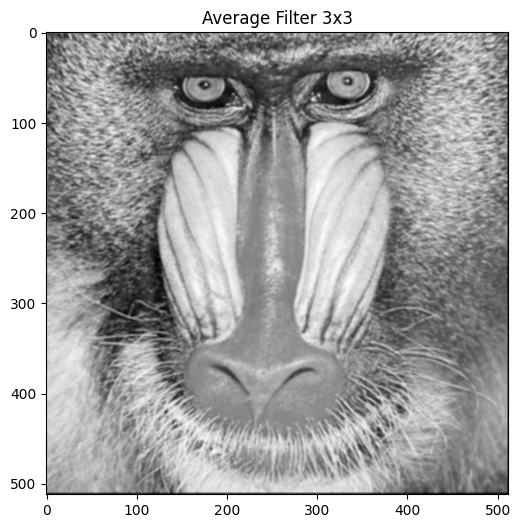

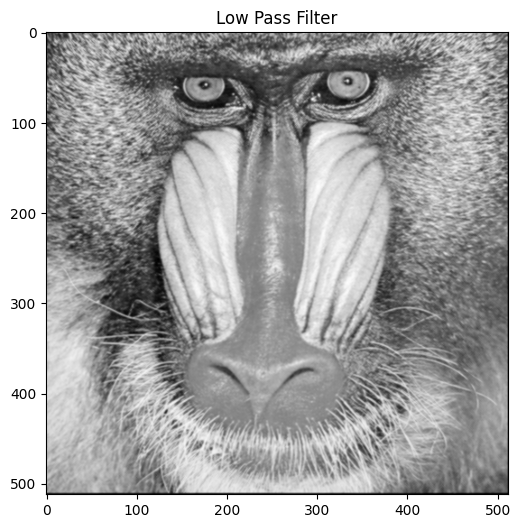

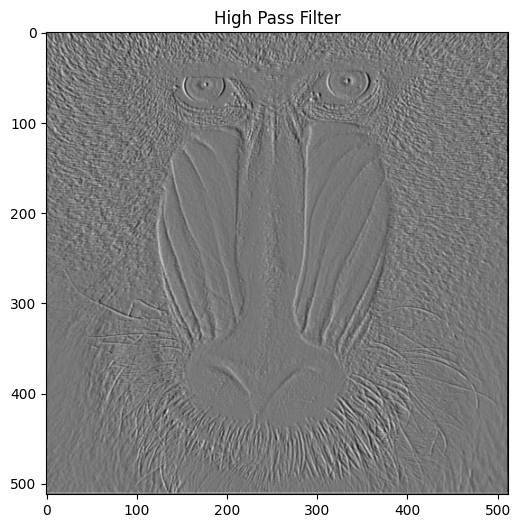

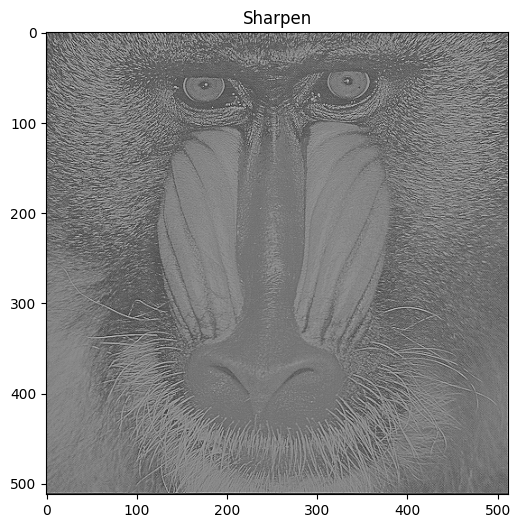

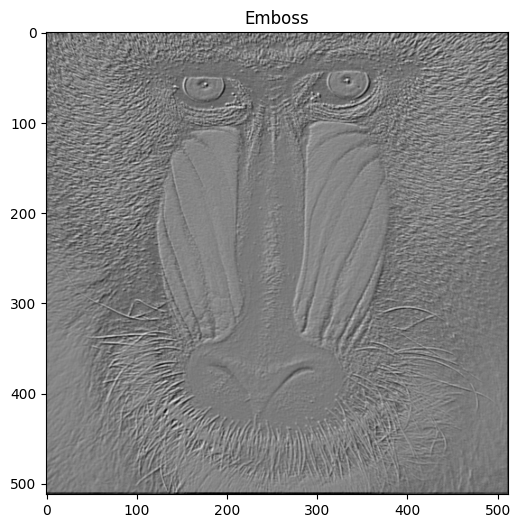

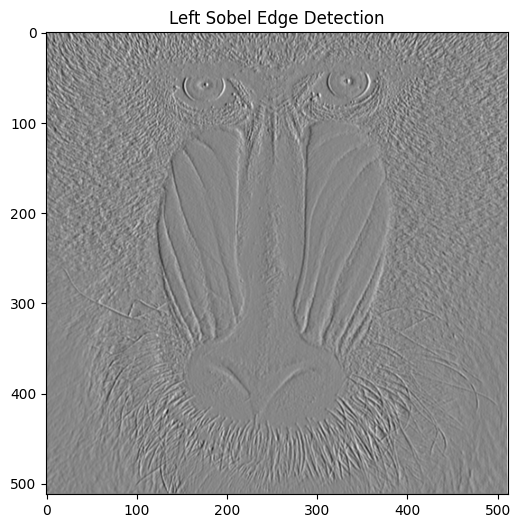

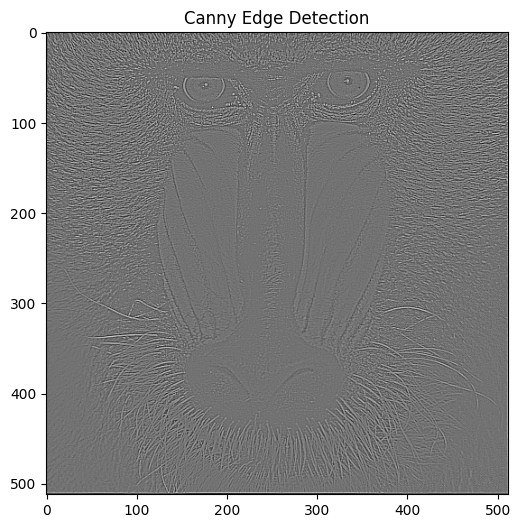

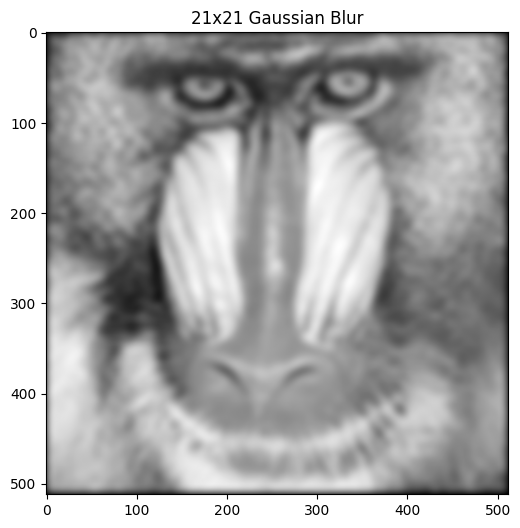

In [12]:
NAMA = 'Anselmus Marcel Putra Andria'
NIM  = '244107020141'
print(NAMA, NIM)

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

# -------------------------------------------------------------------
# 1. Definisi Fungsi Konvolusi 2D Manual (tanpa cv.filter2D)
# -------------------------------------------------------------------
def convolution2d(image, kernel, stride=1, padding=0):
    # Menambahkan padding jika nilai padding > 0
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)

    img_h, img_w = image.shape
    kernel_h, kernel_w = kernel.shape

    # Menghitung ukuran citra keluaran
    out_h = int((img_h - kernel_h) / stride) + 1
    out_w = int((img_w - kernel_w) / stride) + 1

    output = np.zeros((out_h, out_w))

    # Proses konvolusi
    for y in range(0, out_h):
        for x in range(0, out_w):
            sub_img = image[y*stride : y*stride + kernel_h, x*stride : x*stride + kernel_w]
            output[y, x] = np.sum(sub_img * kernel)

    return output

# -------------------------------------------------------------------
# 2. Load Citra Masukan dan Ubah ke Grayscale
# -------------------------------------------------------------------
img = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020141/mandrill.tiff')
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

# -------------------------------------------------------------------
# 3. Definisi Seluruh Kernel Filter (Sesuai Soal D.3)
# -------------------------------------------------------------------
# a. Average Filter (3x3)
kernel_avg = (1.0 / 9.0) * np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
])

# b. Low Pass Filter (3x3)
kernel_lpf = (1.0 / 12.0) * np.array([
    [1, 1, 1],
    [1, 4, 1],
    [1, 1, 1]
])

# c. High Pass Filter (3x3)
kernel_hpf = np.array([
    [-1,  0, 1],
    [-1,  0, 3],
    [-3,  0, 1]
])

# d. Sharpen
kernel_sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

# e. Emboss
kernel_emboss = np.array([
    [-2, -1,  0],
    [-1,  1,  1],
    [ 0,  1,  2]
])

# f. Left Sobel Edge Detection
kernel_left_sobel = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
])

# g. Canny Edge Detection (Kernel Laplasian / Edge Detection)
kernel_canny_edge = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

# h. 21x21 Gaussian Blur
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel_1d = cv.getGaussianKernel(kernel_size, sigma)
kernel_gaussian_21x21 = gaussian_kernel_1d @ gaussian_kernel_1d.transpose()

# -------------------------------------------------------------------
# 4. Melakukan Konvolusi Menggunakan Fungsi convolution2d
# -------------------------------------------------------------------
res_avg        = convolution2d(img_gray, kernel_avg, stride=1, padding=1)
res_lpf        = convolution2d(img_gray, kernel_lpf, stride=1, padding=1)
res_hpf        = convolution2d(img_gray, kernel_hpf, stride=1, padding=1)
res_sharpen    = convolution2d(img_gray, kernel_sharpen, stride=1, padding=1)
res_emboss     = convolution2d(img_gray, kernel_emboss, stride=1, padding=1)
res_left_sobel = convolution2d(img_gray, kernel_left_sobel, stride=1, padding=1)
res_canny_edge = convolution2d(img_gray, kernel_canny_edge, stride=1, padding=1)
res_gauss_21   = convolution2d(img_gray, kernel_gaussian_21x21, stride=1, padding=10)

# -------------------------------------------------------------------
# 5. Menampilkan Hasil Konvolusi
# -------------------------------------------------------------------
filters = [
    ("Average Filter 3x3", res_avg),
    ("Low Pass Filter", res_lpf),
    ("High Pass Filter", res_hpf),
    ("Sharpen", res_sharpen),
    ("Emboss", res_emboss),
    ("Left Sobel Edge Detection", res_left_sobel),
    ("Canny Edge Detection", res_canny_edge),
    ("21x21 Gaussian Blur", res_gauss_21)
]

for title, res in filters:
    plt.figure(figsize=(6, 6))
    plt.imshow(res, cmap='gray')
    plt.title(title)
    plt.axis('on')
    plt.show()